<a href="https://colab.research.google.com/github/singhshahrahul/AI-ML/blob/main/11_foodvision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. Tools

In [ ]:
# !pip install --upgrade protobuf tensorflow-metadata tensorflow-datasets

In [ ]:
# !rm -rf /root/tensorflow_datasets/food101 #only if you have previous hafl build
# !pip install importlib_resources

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks, mixed_precision

In [ ]:
#Get helper_functions.py
!wget https://raw.githubusercontent.com/singhshahrahul/AI-ML/refs/heads/main/helper_function.py

#import helpoer functions
from helper_function import plot_loss_curves, compare_historys, create_tensorboard_callback

--2026-09-06 09:17:33--  https://raw.githubusercontent.com/singhshahrahul/AI-ML/refs/heads/main/helper_function.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11757 (11K) [text/plain]
Saving to: ‘helper_function.py.1’

helper_function.py. 100%[===================>]  11.48K  --.-KB/s    in 0s      

2026-09-06 09:17:33 (72.1 MB/s) - ‘helper_function.py.1’ saved [11757/11757]



#1. Use TensorFlow dataset to download data

In [ ]:
#Get TensorFlow dataset
import tensorflow_datasets as tfds

#get all available datasets in tfds
builder = tfds.list_builders()

#check for food101 dataset
print("food101" in builder)

True


In [ ]:
#load the data
(train_data, test_data), df_info = tfds.load(name = "food101",
                                             split = ["train", "validation"],
                                             shuffle_files = True,
                                             as_supervised = True, #return data in tuple format (data, label)
                                             with_info = True #gives meta data
                                             )

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.GVX7R3_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.GVX7R3_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


#Exploring the Food101 data

In [ ]:
df_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [ ]:
class_names = df_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [ ]:
#Take one sample from training data
one_sample = train_data.take(1) #format (image_tensor, label)
one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

let's loop through our sample

In [ ]:
for image, label in one_sample:
  print(f"""
  Image shape: {image.shape}
  Image datatype: {image.dtype}
  Target class from Food101: {label}
  class name (str form): {class_names[label.numpy()]}
  """)


  Image shape: (382, 512, 3)
  Image datatype: <dtype: 'uint8'>
  Target class from Food101: 52
  class name (str form): gyoza
  


In [ ]:
image

<tf.Tensor: shape=(382, 512, 3), dtype=uint8, numpy=
array([[[207, 220, 237],
        [207, 220, 237],
        [207, 220, 236],
        ...,
        [ 10,  11,  13],
        [ 11,  12,  14],
        [ 12,  13,  15]],

       [[208, 219, 237],
        [207, 220, 236],
        [208, 220, 236],
        ...,
        [  9,  10,  12],
        [ 10,  11,  13],
        [ 11,  12,  14]],

       [[216, 225, 242],
        [213, 225, 239],
        [214, 223, 238],
        ...,
        [ 11,  12,  14],
        [ 12,  13,  15],
        [ 12,  13,  15]],

       ...,

       [[ 33,  10,  16],
        [ 34,  11,  17],
        [ 33,  12,  17],
        ...,
        [ 10,   6,   5],
        [ 13,   7,   7],
        [ 15,   9,   9]],

       [[ 37,  12,  18],
        [ 36,  13,  19],
        [ 35,  15,  17],
        ...,
        [ 14,  10,   9],
        [ 19,  13,  13],
        [ 21,  15,  15]],

       [[ 39,  14,  20],
        [ 37,  14,  20],
        [ 36,  14,  17],
        ...,
        [ 19,  15,  1

In [ ]:
#What are the min and max values?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

#Plot an image from dataset

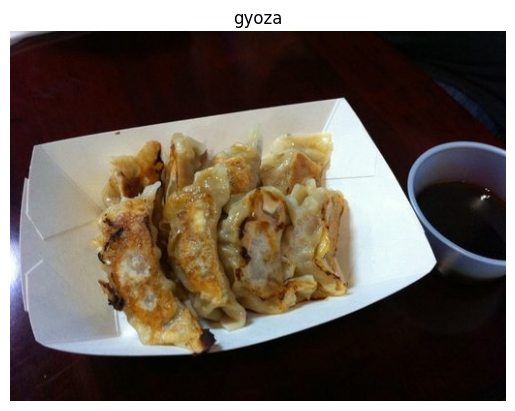

In [ ]:
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False);

#2. Start building the model (Feature Extraction)

In [ ]:
def preprocess_img(image, label, img_shape=224):
  image = tf.image.resize(image, [img_shape, img_shape])
  # image = image/255. #not required for EfficientNet
  return tf.cast(image, tf.float32), label

In [ ]:
#Preprocess a single image
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}...,\nShape: {image.shape}, \nDatatype: {image.dtype}\n")
print(f"Image after preprocessing:\n {preprocessed_img[:2]}...,\nShape: {preprocessed_img.shape}, \nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[207 220 237]
  [207 220 237]
  [207 220 236]
  ...
  [ 10  11  13]
  [ 11  12  14]
  [ 12  13  15]]

 [[208 219 237]
  [207 220 236]
  [208 220 236]
  ...
  [  9  10  12]
  [ 10  11  13]
  [ 11  12  14]]]...,
Shape: (382, 512, 3), 
Datatype: <dtype: 'uint8'>

Image after preprocessing:
 [[[207.12596  219.87404  236.77328 ]
  [206.75159  219.39891  235.39891 ]
  [206.33514  216.86098  232.36958 ]
  ...
  [ 10.433058  11.433058  13.433058]
  [  9.974804  10.974804  12.974804]
  [ 11.004499  12.004499  14.004499]]

 [[214.51498  225.25287  240.26627 ]
  [214.24043  223.17825  238.07462 ]
  [213.40561  221.28954  234.25638 ]
  ...
  [ 12.571472  13.571472  15.571472]
  [ 11.928558  12.928558  14.928558]
  [ 11.941964  12.941964  14.941964]]]...,
Shape: (224, 224, 3), 
Datatype: <dtype: 'float32'>


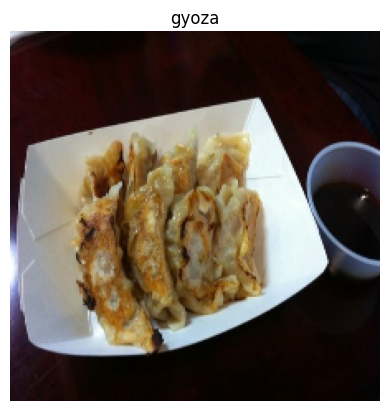

In [ ]:
#we can still plot our preprocessed image
plt.imshow(preprocessed_img/255.)
plt.title(class_names[label])
plt.axis(False);

#Batch and prepare datasets & Setup mixed precision training

In [ ]:
img_size = 224
batch_size = 32
epochs = 3
num_classes = len(class_names)
checkpoint_path = "model_checkpoints/efficientnetb0_best.weights.h5"
# enable_mixed_precision = True

#Set mixed precision (if supported)
# if enable_mixed_precision:
#   mixed_precision.set_global_policy("mixed_float16")

#Dataset pipelines
def prepare_dataset(ds, is_train=True):
  ds = ds.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
  if is_train:
    ds = ds.shuffle(1000)
  return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_data = prepare_dataset(train_data, is_train=True)
test_data = prepare_dataset(test_data, is_train=False)

In [ ]:
#Callbacks
tensorboard_cb = create_tensorboard_callback("training_logs", "efficientnetb0_101_classes_feature_extract")
checkpoint_cb = callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor = "val_accuracy",
    save_best_only = True,
    save_weights_only = True,
    verbose = 0
)

Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_feature_extract/20260906-100708


#Modle Creation

In [ ]:
#Function for model creation
def build_model(input_shape=(img_size, img_size, 3), num_classes=num_classes):
  base_model = tf.keras.applications.EfficientNetB0(include_top=False)
  base_model.trainable = False

  inputs = layers.Input(shape=input_shape, name = "input_layer")
  x = base_model(inputs, training=False)
  x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
  x = layers.Dense(num_classes)(x)
  outputs = layers.Activation("softmax", dtype="float32", name="softmax")(x)

  model = models.Model(inputs, outputs)
  return model

In [ ]:
model = build_model()

model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["accuracy"]
)

In [ ]:
#Model training
history = model.fit(train_data, epochs = epochs,
                    validation_data = test_data,
                    validation_steps = int(0.15*len(test_data)),
                    callbacks=[tensorboard_cb, checkpoint_cb])

Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 245s 86ms/step - accuracy: 0.5687 - loss: 1.7738 - val_accuracy: 0.6936 - val_loss: 1.1316
Epoch 2/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 202s 73ms/step - accuracy: 0.6718 - loss: 1.2688 - val_accuracy: 0.7182 - val_loss: 1.0302
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - accuracy: 0.7045 - loss: 1.1302 - val_accuracy: 0.7251 - val_loss: 0.9899


In [ ]:
#model evaluation
results = model.evaluate(test_data)
print("Test Accuracy: ", results[1])

790/790 ━━━━━━━━━━━━━━━━━━━━ 79s 100ms/step - accuracy: 0.7249 - loss: 1.0024
Test Accuracy:  0.7249109148979187


#3. Fine-Tuning

In [ ]:
#Load the saved weights (feature extraction)
model.load_weights(checkpoint_path)

In [ ]:
#Re-compile with a lower learning rate for fine-tuning
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(1e-4),
    metrics=["accuracy"]
)

In [ ]:
#setup callbacks (best-only saving, early stopping, lr reducer)
fine_tune_checkpoint_path = "fine_tune_best_model.weights.h5"

model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    fine_tune_checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-7
)

In [ ]:
history_fine_tune = model.fit(train_data, epochs = 100, validation_data = test_data,
                              validation_steps = int(0.15*len(test_data)),
                              callbacks=[create_tensorboard_callback("training_logs", "efficientb0_fine_tuning"),
                                         model_checkpoint_cb,
                                         early_stopping_cb,
                                         reduce_lr_cb])

Saving TensorBoard log files to: training_logs/efficientb0_fine_tuning/20260906-103908
Epoch 1/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7369 - loss: 1.0036
Epoch 1: val_loss improved from None to 0.95790, saving model to fine_tune_best_model.weights.h5

Epoch 1: finished saving model to fine_tune_best_model.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 261s 98ms/step - accuracy: 0.7461 - loss: 0.9751 - val_accuracy: 0.7376 - val_loss: 0.9579 - learning_rate: 1.0000e-04
Epoch 2/100
2366/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7493 - loss: 0.9690
Epoch 2: val_loss improved from 0.95790 to 0.94847, saving model to fine_tune_best_model.weights.h5

Epoch 2: finished saving model to fine_tune_best_model.weights.h5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 69ms/step - accuracy: 0.7519 - loss: 0.9596 - val_accuracy: 0.7397 - val_loss: 0.9485 - learning_rate: 1.0000e-04
Epoch 3/100
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7495 - loss: 0.9694
Epoch 3: val

In [ ]:
#Load best fine-tuned weights
model.load_weights(fine_tune_checkpoint_path)

#Final evaluation
final_results = model.evaluate(test_data)
print("Final Test Accuracy: ", final_results[1])

In [ ]:
#loss and accuracy of Feature extractor model
from helper_tools import plot_loss_curves

plot_loss_curves(history)

In [ ]:
#loss and accuracy after fine tune

compare_historys(history, history_fine_tune, initial_epochs=3)

prediction


In [ ]:
# 1. Get model predictions (logits or probabilities)
y_pred_probs = model.predict(test_data)

# 2. Convert probabilities to predicted class labels (highest prob = chosen class)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Get true labels (y_true) from test_data
# Correctly unbatch and get true labels
y_true = np.array([label.numpy() for _, label in test_data.unbatch()])

In [ ]:
# Plot a confusion matrix with all predictions
from helper_tools import make_confusion_matrix
import itertools

make_confusion_matrix(y_true=y_true,
                      y_pred=y_pred,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)